# Project 2: Exploratory Data Analysis (EDA) Report
---
## Assigned Topic:
__Wind Turbine__

## Selected Problem Statement: 
__Approach: Renewable Energy Private Equity Investment
Problem Statement: A private equity firm focused on renewable energy aims to acquire U.S. wind farms but requires deeper insight into the specific structural characteristics and geographic locations that drive peak energy efficiency. To guide these acquisitions, the Investment Committee must evaluate historical Net Generation (MWh) data across various Census Regions, segmented by turbine specifications and technical details. By spotting niche opportunities, distinguishing the physical configurations and regions with the strongest historical performance, the firm can strategically target assets that meet proven benchmarks for high energy output.__

## 1. Introduction & Objectives
### 1.1 Context & Background
*A private equity firm focused on renewable energy is planning to acquire wind farms across the United States. Before committing to acquisitions, the firm needs to understand how technical turbine specifications (such as rated capacity, hub height, and rotor diameter) and geographic location influence performance and efficiency. This analysis draws on the official USWTDB (U.S. Wind Turbine Database), which contains records for over 70,000 turbines across the country, supplemented with state-level data on wind speed/power, electricity rates, and electricity bills — allowing us to connect technical performance with economic feasibility.*


### 1.2 Core Analytical Objectives
*To solve this problem, our analysis will answer these simple questions:*
* Which regions have the strongest performance?
* How do turbine size and rotor size relate to each other, and to overall performance?
* What specs (capacity, rotor size, hub height) do the best-performing turbines share?
* Are there rare turbine models that perform much better than average?

---

## 2. Environment Setup & Data Collection
To begin our analysis, we need to set up our programming environment and load our datasets. We import the standard pandas and numpy libraries using their industry-standard aliases. To ensure the project can run smoothly on any computer (replicability), we load all the data files using relative paths, assuming they are placed in the same project folder.

In [28]:
# Import libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


In [29]:
# Load data using strictly relative file paths
wind_turbines = pd.read_csv('wind-turbines.csv', encoding='latin-1')
avg_bills = pd.read_csv('./extra/average_electricity_bills.csv', thousands=',')
avg_rates = pd.read_csv('./extra/average_electricity_rates.csv')
windiest_states = pd.read_csv('./extra/windiest-states-in-the-us.-2025.csv')

# Create a working copy so the raw data stays untouched
wind_clean = wind_turbines.copy()

---
## 3. Data Handling
### 3.1 Initial Assessment

In [30]:
# Shape of each dataset
print("wind_clean shape:", wind_clean.shape)
print("avg_bills shape:", avg_bills.shape)
print("avg_rates shape:", avg_rates.shape)
print("windiest_states shape:", windiest_states.shape)


wind_clean shape: (70808, 27)
avg_bills shape: (50, 4)
avg_rates shape: (51, 4)
windiest_states shape: (50, 6)


In [31]:
# Check info
wind_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 70808 entries, 0 to 70807
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   case_id        70808 non-null  int64  
 1   faa_ors        65016 non-null  str    
 2   faa_asn        65686 non-null  str    
 3   usgs_pr_id     38263 non-null  float64
 4   eia_id         65015 non-null  float64
 5   t_state        70808 non-null  str    
 6   t_county       70808 non-null  str    
 7   t_fips         70808 non-null  int64  
 8   p_name         70808 non-null  str    
 9   p_year         70195 non-null  float64
 10  p_tnum         70808 non-null  int64  
 11  p_cap          66326 non-null  float64
 12  t_manu         65168 non-null  str    
 13  t_model        65031 non-null  str    
 14  t_cap          65328 non-null  float64
 15  t_hh           64628 non-null  float64
 16  t_rd           64874 non-null  float64
 17  t_rsa          64874 non-null  float64
 18  t_ttlh         64

In [32]:
#null values
wind_clean.isnull().sum().sort_values(ascending=False)


retrofit_year    64822
usgs_pr_id       32545
t_img_date        8316
t_hh              6180
t_ttlh            6180
t_rd              5934
t_rsa             5934
eia_id            5793
faa_ors           5792
t_model           5777
t_manu            5640
t_cap             5480
faa_asn           5122
p_cap             4482
p_year             613
t_state              0
case_id              0
t_fips               0
t_county             0
p_tnum               0
p_name               0
t_conf_atr           0
retrofit             0
t_conf_loc           0
t_img_srce           0
xlong                0
ylat                 0
dtype: int64

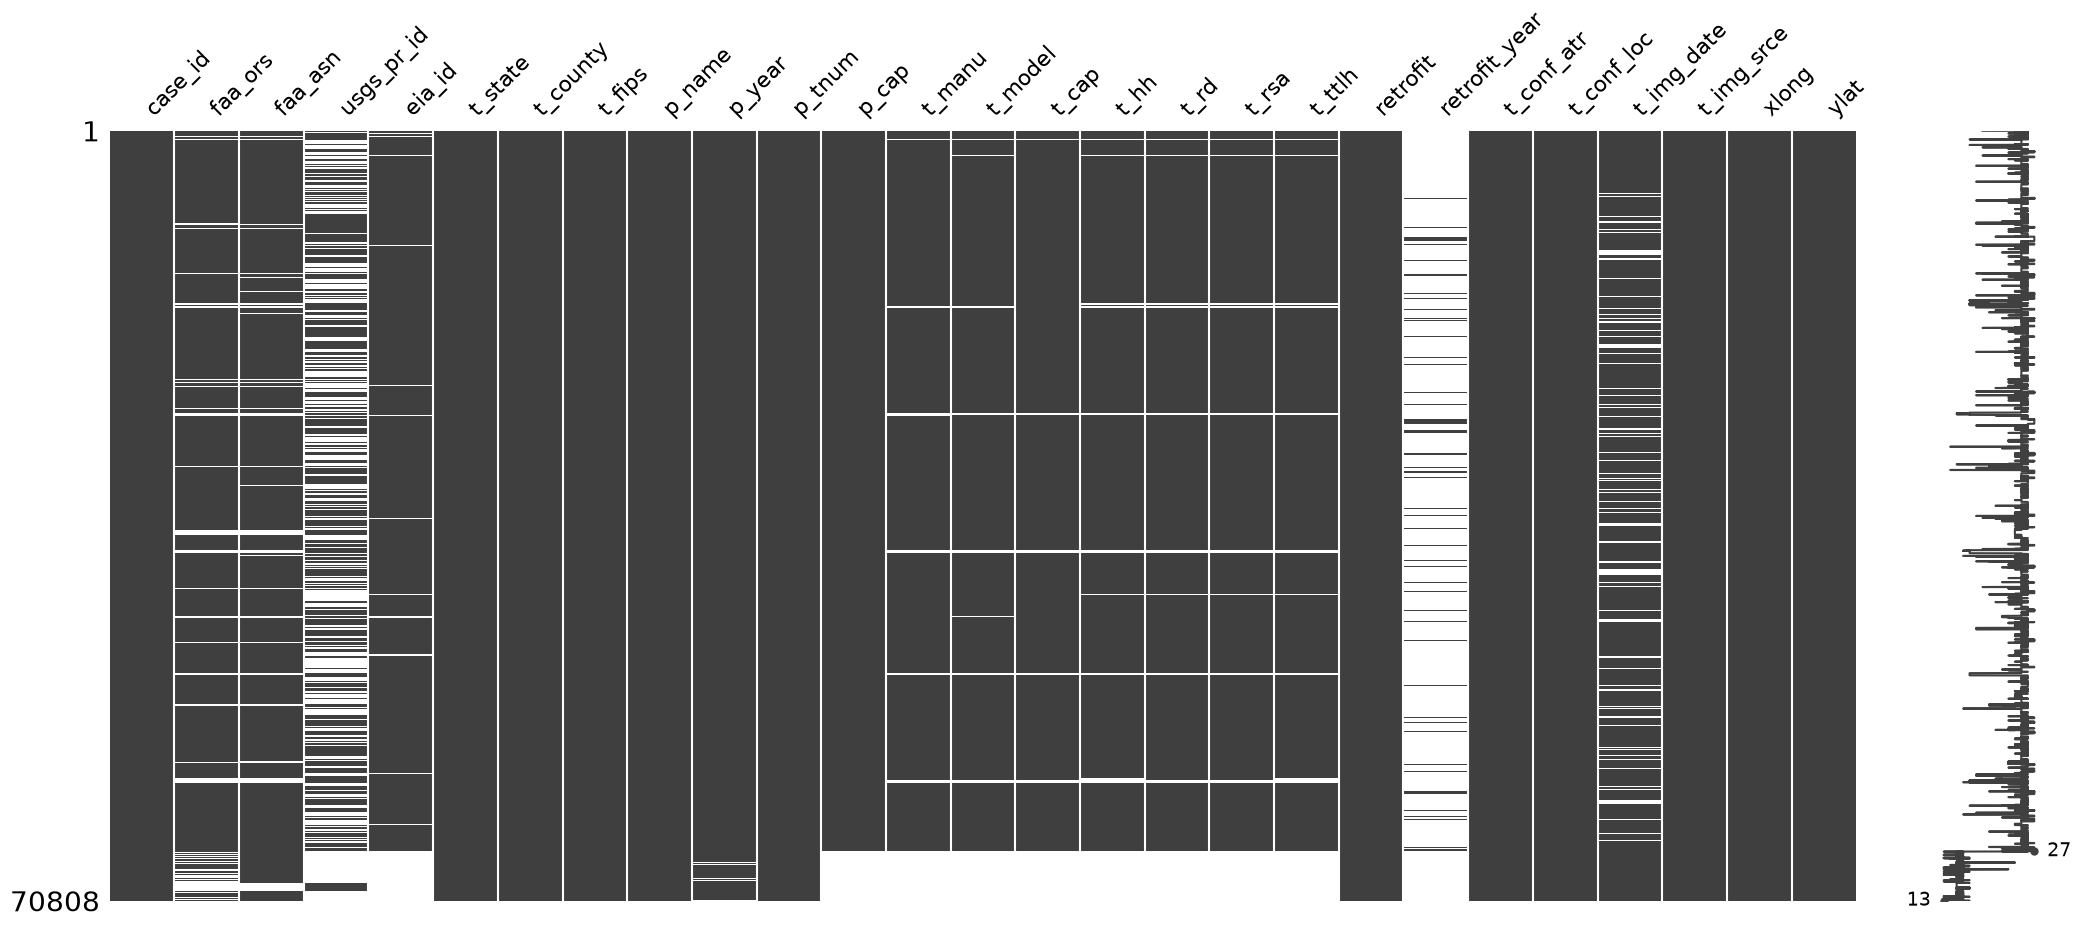

In [33]:
# Visual check of missing data pattern
msno.matrix(wind_clean)
plt.show()

In [34]:
wind_clean.describe()

,case_id,usgs_pr_id,eia_id,t_fips,p_year,p_tnum,p_cap,t_cap,t_hh,t_rd,t_rsa,t_ttlh,retrofit,retrofit_year,t_conf_atr,t_conf_loc,xlong,ylat
count,7.080800e+04,38263.000000,65015.000000,70808.000000,70195.000000,70808.000000,66326.000000,65328.000000,64628.000000,64874.000000,64874.000000,64628.000000,70808.000000,5986.000000,70808.000000,70808.000000,70808.000000,70808.000000
mean,3.058490e+06,27523.587225,57877.751642,32244.494097,2011.650659,104.360552,170.176128,1963.534151,81.054571,95.663717,7618.500657,129.050593,0.084538,2018.640327,2.766509,2.883784,-100.086457,38.479503
std,3.242377e+04,13564.446593,5984.516487,15498.246596,7.879099,93.954786,104.478693,717.067912,12.028726,23.424346,3309.229282,22.185981,0.278196,1.112294,0.597195,0.462326,11.141025,5.429730
min,3.000001e+06,1.000000,90.000000,2013.000000,1981.000000,1.000000,0.050000,50.000000,19.000000,13.400000,141.030000,30.400000,0.000000,2015.000000,1.000000,1.000000,-171.713074,13.389381
25%,3.032230e+06,18625.500000,56763.000000,19081.000000,2008.000000,56.000000,99.000000,1500.000000,80.000000,82.000000,5281.020000,121.000000,0.000000,2018.000000,3.000000,3.000000,-103.037155,34.428043
50%,3.050978e+06,28598.000000,57752.000000,35057.000000,2012.000000,85.000000,158.000000,2000.000000,80.000000,100.000000,7853.980000,130.100000,0.000000,2019.000000,3.000000,3.000000,-99.393761,39.052442
75%,3.090448e+06,38719.500000,60338.000000,48141.000000,2018.000000,121.000000,211.220000,2300.000000,87.000000,110.000000,9503.320000,145.100000,0.000000,2020.000000,3.000000,3.000000,-95.202499,42.812810
max,3.118671e+06,49135.000000,65270.000000,72133.000000,2021.000000,731.000000,525.020000,6000.000000,131.000000,155.000000,18869.190000,199.600000,1.000000,2020.000000,3.000000,3.000000,144.722656,66.839905


In [35]:
# check duplicates
wind_clean.duplicated().sum()

np.int64(0)

In [36]:
# Check extra datasets individually
print(avg_bills.dtypes)
print(avg_bills.isnull().sum())
avg_bills.head()

State              str
Residential    float64
Commercial     float64
Average        float64
dtype: object
State          0
Residential    0
Commercial     0
Average        0
dtype: int64


,State,Residential,Commercial,Average
0,Alabama,115.00,679.26,397.13
1,Alaska,198.10,1201.93,700.02
2,Arizona,118.76,645.96,382.36
3,Arkansas,101.92,577.55,339.74
4,California,258.38,1400.90,829.64


In [37]:
print(avg_rates.dtypes)
print(avg_rates.isnull().sum())
avg_rates.head()

State              str
Residential    float64
Commercial     float64
Average        float64
dtype: object
State          0
Residential    0
Commercial     0
Average        0
dtype: int64


,State,Residential,Commercial,Average
0,Alabama,14.91,13.83,14.37
1,Alaska,22.38,18.43,20.41
2,Arizona,15.20,11.92,13.56
3,Arkansas,11.74,10.11,10.93
4,California,30.55,23.13,26.84


In [38]:
print(windiest_states.dtypes)
print(windiest_states.isnull().sum())
windiest_states.head()

stateFlagCode                        float64
state                                    str
WindiestStatesAverageWindSpeedMPH    float64
MeanWindSpeed328ft                   float64
MeanWindPower328ft                     int64
MeanWindSpeed33ft                    float64
dtype: object
stateFlagCode                        50
state                                 0
WindiestStatesAverageWindSpeedMPH     0
MeanWindSpeed328ft                    0
MeanWindPower328ft                    0
MeanWindSpeed33ft                     0
dtype: int64


,stateFlagCode,state,WindiestStatesAverageWindSpeedMPH,MeanWindSpeed328ft,MeanWindPower328ft,MeanWindSpeed33ft
0,NaN,South Dakota,21.32,20.3,722,12.8
1,NaN,Montana,21.03,20.5,985,13.5
2,NaN,Wyoming,20.88,21.5,964,14.1
3,NaN,Idaho,20.59,16.5,472,10.6
4,NaN,Colorado,20.16,20.0,751,12.8


### 3.2 Handling Missing Values

In [39]:
# Drop irrelevant ID/reference columns
cols_to_drop = ['usgs_pr_id', 'faa_ors', 'faa_asn', 't_img_date', 't_img_srce']
wind_clean = wind_clean.drop(columns=cols_to_drop)

# retrofit_year: missing is expected when retrofit == 0, fill with 0
wind_clean['retrofit_year'] = wind_clean['retrofit_year'].fillna(0)

# Drop rows missing p_cap (critical for our net_gen_proxy)
wind_clean = wind_clean.dropna(subset=['p_cap'])

# p_year: negligible missing, safe to drop
wind_clean = wind_clean.dropna(subset=['p_year'])

# windiest_states: drop empty column
windiest_states = windiest_states.drop(columns=['stateFlagCode'])

# Final check
print("Final wind_clean shape:", wind_clean.shape)
print(wind_clean.isnull().sum().sort_values(ascending=False))

Final wind_clean shape: (66318, 22)
t_ttlh           1696
t_hh             1696
t_rd             1451
t_rsa            1451
eia_id           1307
t_model          1292
t_manu           1161
t_cap             996
p_name              0
t_state             0
case_id             0
t_fips              0
t_county            0
p_cap               0
p_tnum              0
p_year              0
retrofit            0
retrofit_year       0
t_conf_atr          0
t_conf_loc          0
xlong               0
ylat                0
dtype: int64


### 3.3 Standardizing Manufacturer Names

In [40]:
# Check the dataset for manufacturer name variants
display(wind_clean[wind_clean['t_manu'].str.lower().str.contains('siemens')]['t_manu'].value_counts())
display(wind_clean[wind_clean['t_manu'].str.lower().str.contains('gamesa')]['t_manu'].value_counts())


t_manu
Siemens                            5035
Siemens Gamesa Renewable Energy    2043
Name: count, dtype: int64

t_manu
Gamesa                             3077
Siemens Gamesa Renewable Energy    2043
Name: count, dtype: int64

In [41]:
# Unify manufacturer name variants under one standard name each
manufactor = {'Siemens Gamesa Renewable Energy':'Siemens','Gamesa':'Siemens' ,"Goldwind Americas":"Goldwind" }
# Apply the mapping to standardize manufacturer names
wind_clean['t_manu']=wind_clean['t_manu'].replace(manufactor)

In [42]:
# Check the results
wind_clean['t_manu'].value_counts()

t_manu
GE Wind                                                                     29131
Vestas                                                                      16259
Siemens                                                                     10155
Mitsubishi                                                                   2620
Nordex                                                                       1591
Suzlon                                                                       1316
Acciona                                                                       758
REpower                                                                       574
NEG Micon                                                                     529
Enron                                                                         396
Bonus                                                                         305
Clipper                                                                       285
Goldwind 

### 3.4 Building Census Region

In [43]:
# Define a function to map each state abbreviation to its US Census Region
def assign_region(state):
    if state in ['ME', 'NH', 'VT', 'MA', 'RI', 'CT', 'NY', 'PA', 'NJ']:
        return 'Northeast'
    elif state in ['IL', 'IN', 'MI', 'OH', 'WI', 'IA', 'KS', 'MN', 'MO', 'NE', 'ND', 'SD']:
        return 'Midwest'
    elif state in ['DE', 'FL', 'GA', 'MD', 'NC', 'SC', 'VA', 'WV', 'AL', 'KY', 'MS', 'TN', 'AR', 'LA', 'OK', 'TX', 'DC']:
        return 'South'
    elif state in ['AZ', 'CO', 'ID', 'MT', 'NV', 'NM', 'UT', 'WY', 'AK', 'CA', 'HI', 'OR', 'WA']:
        return 'West'
    else:
        return 'Unknown'
        
# Apply the mapping function to create a new region column
wind_clean['census_region'] = wind_clean['t_state'].apply(assign_region)

wind_clean.head()



,case_id,eia_id,t_state,t_county,t_fips,p_name,p_year,p_tnum,p_cap,t_manu,...,t_rd,t_rsa,t_ttlh,retrofit,retrofit_year,t_conf_atr,t_conf_loc,xlong,ylat,census_region
0,3072661,52161.0,CA,Kern County,6029,251 Wind,1987.0,194,18.43,Vestas,...,NaN,NaN,NaN,0,0.0,2,3,-118.363762,35.077908,West
1,3072695,52161.0,CA,Kern County,6029,251 Wind,1987.0,194,18.43,Vestas,...,NaN,NaN,NaN,0,0.0,2,3,-118.364410,35.077435,West
2,3072704,52161.0,CA,Kern County,6029,251 Wind,1987.0,194,18.43,Vestas,...,NaN,NaN,NaN,0,0.0,2,3,-118.364197,35.077644,West
3,3063272,NaN,IA,Story County,19169,30 MW Iowa DG Portfolio,2017.0,10,30.00,Nordex,...,125.0,12271.85,150.0,0,0.0,3,3,-93.430367,42.028233,Midwest
4,3053390,NaN,IA,Boone County,19015,30 MW Iowa DG Portfolio,2017.0,10,30.00,Nordex,...,125.0,12271.85,150.0,0,0.0,3,3,-93.700424,41.977608,Midwest


In [44]:
#checking for the values that are unknown and drop them 
print(wind_clean[wind_clean['census_region'] == 'Unknown']['t_state'].value_counts(dropna=False))
wind_clean = wind_clean[wind_clean['census_region'] != 'Unknown']
display(wind_clean.head())
display(wind_clean.shape)

t_state
PR    60
GU     1
Name: count, dtype: int64


,case_id,eia_id,t_state,t_county,t_fips,p_name,p_year,p_tnum,p_cap,t_manu,...,t_rd,t_rsa,t_ttlh,retrofit,retrofit_year,t_conf_atr,t_conf_loc,xlong,ylat,census_region
0,3072661,52161.0,CA,Kern County,6029,251 Wind,1987.0,194,18.43,Vestas,...,NaN,NaN,NaN,0,0.0,2,3,-118.363762,35.077908,West
1,3072695,52161.0,CA,Kern County,6029,251 Wind,1987.0,194,18.43,Vestas,...,NaN,NaN,NaN,0,0.0,2,3,-118.364410,35.077435,West
2,3072704,52161.0,CA,Kern County,6029,251 Wind,1987.0,194,18.43,Vestas,...,NaN,NaN,NaN,0,0.0,2,3,-118.364197,35.077644,West
3,3063272,NaN,IA,Story County,19169,30 MW Iowa DG Portfolio,2017.0,10,30.00,Nordex,...,125.0,12271.85,150.0,0,0.0,3,3,-93.430367,42.028233,Midwest
4,3053390,NaN,IA,Boone County,19015,30 MW Iowa DG Portfolio,2017.0,10,30.00,Nordex,...,125.0,12271.85,150.0,0,0.0,3,3,-93.700424,41.977608,Midwest


(66257, 23)

### 3.5 Standardizing State Names (Extra Datasets)

In [45]:
# Standardize state names to abbreviations across all extra datasets
# so they can be merged with wind_clean (which uses t_state as abbreviation)
us_state_abbrev = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR','California':'CA','Colorado':'CO',
    'Connecticut':'CT','Delaware':'DE','Florida':'FL','Georgia':'GA','Hawaii':'HI','Idaho':'ID',
    'Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS','Kentucky':'KY','Louisiana':'LA',
    'Maine':'ME','Maryland':'MD','Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
    'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV','New Hampshire':'NH','New Jersey':'NJ',
    'New Mexico':'NM','New York':'NY','North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK',
    'Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC','South Dakota':'SD',
    'Tennessee':'TN','Texas':'TX','Utah':'UT','Vermont':'VT','Virginia':'VA','Washington':'WA',
    'West Virginia':'WV','Wisconsin':'WI','Wyoming':'WY','District of Columbia':'DC'}

# Apply the mapping to each extra dataset's state column
windiest_states['state'] = windiest_states['state'].map(us_state_abbrev)
avg_bills['State']=avg_bills['State'].map(us_state_abbrev)
avg_rates['State']=avg_rates['State'].map(us_state_abbrev)

# Check for any states that failed to map (would show as NaN)
print("windiest_states unmatched:", windiest_states['state'].isnull().sum())
print("avg_bills unmatched:", avg_bills['State'].isnull().sum())
print("avg_rates unmatched:", avg_rates['State'].isnull().sum())

windiest_states unmatched: 0
avg_bills unmatched: 0
avg_rates unmatched: 0


### 3.6 Merging Datasets & Feature Engineering

In [46]:
# Merge wind power data into wind_clean using the standardized state codes
wind_clean = pd.merge(
    wind_clean,
    windiest_states[['state', 'MeanWindPower328ft']],
    left_on='t_state', right_on='state',
    how='left'
)

# Drop the duplicate state column left over from the merge
wind_clean = wind_clean.drop(columns=['state'])

In [47]:
# Confirm the merge worked (should be 0 unmatched rows)
print("Unmatched rows after merge:", wind_clean['MeanWindPower328ft'].isnull().sum())
wind_clean.head()

Unmatched rows after merge: 0


,case_id,eia_id,t_state,t_county,t_fips,p_name,p_year,p_tnum,p_cap,t_manu,...,t_rsa,t_ttlh,retrofit,retrofit_year,t_conf_atr,t_conf_loc,xlong,ylat,census_region,MeanWindPower328ft
0,3072661,52161.0,CA,Kern County,6029,251 Wind,1987.0,194,18.43,Vestas,...,NaN,NaN,0,0.0,2,3,-118.363762,35.077908,West,649
1,3072695,52161.0,CA,Kern County,6029,251 Wind,1987.0,194,18.43,Vestas,...,NaN,NaN,0,0.0,2,3,-118.364410,35.077435,West,649
2,3072704,52161.0,CA,Kern County,6029,251 Wind,1987.0,194,18.43,Vestas,...,NaN,NaN,0,0.0,2,3,-118.364197,35.077644,West,649
3,3063272,NaN,IA,Story County,19169,30 MW Iowa DG Portfolio,2017.0,10,30.00,Nordex,...,12271.85,150.0,0,0.0,3,3,-93.430367,42.028233,Midwest,542
4,3053390,NaN,IA,Boone County,19015,30 MW Iowa DG Portfolio,2017.0,10,30.00,Nordex,...,12271.85,150.0,0,0.0,3,3,-93.700424,41.977608,Midwest,542


In [48]:
# Estimate a capacity factor per state (scaled 20%-45% based on wind strength)
# Windier states get a higher capacity factor, calmer states get a lower one
wind_clean['capacity_factor_est'] = np.interp(
    wind_clean['MeanWindPower328ft'],
    (wind_clean['MeanWindPower328ft'].min(), wind_clean['MeanWindPower328ft'].max()),
    (0.20, 0.45)
)

# Estimated Net Generation (MWh) = capacity (MW) x hours in a year x capacity factor
# Real Net Generation data wasn't available — this is an estimate, noted as a
# limitation in Section 5.3
wind_clean['net_gen_proxy'] = wind_clean['p_cap'] * 8760 * wind_clean['capacity_factor_est']

wind_clean[['p_name', 't_state', 'p_cap', 'MeanWindPower328ft', 'capacity_factor_est', 'net_gen_proxy']].head()

,p_name,t_state,p_cap,MeanWindPower328ft,capacity_factor_est,net_gen_proxy
0,251 Wind,CA,18.43,649,0.258519,41737.082771
1,251 Wind,CA,18.43,649,0.258519,41737.082771
2,251 Wind,CA,18.43,649,0.258519,41737.082771
3,30 MW Iowa DG Portfolio,IA,30.00,542,0.237221,62341.767516
4,30 MW Iowa DG Portfolio,IA,30.00,542,0.237221,62341.767516


---
## 4. Exploratory Data Analysis (EDA)


### 4.1. Descriptive Statistics

In [49]:
# Overall summary statistics for our estimated Net Generation
wind_clean['net_gen_proxy'].describe()

count    6.625700e+04
mean     3.750054e+05
std      2.319237e+05
min      9.936951e+01
25%      2.112506e+05
50%      3.435737e+05
75%      4.730785e+05
max      1.415940e+06
Name: net_gen_proxy, dtype: float64

In [50]:
# Summary statistics grouped by Census Region, sorted by average performance
region_summary = wind_clean.groupby('census_region')['net_gen_proxy'].agg(
    ['mean', 'median', 'sum', 'count']
).sort_values('mean', ascending=False)
region_summary

,mean,median,sum,count
census_region,,,,
South,422339.262598,419447.770701,9.226424e+09,21846
Midwest,376895.152254,342571.098726,9.462330e+09,25106
West,338709.807242,294636.427548,5.654083e+09,16693
Northeast,192917.127219,188981.656051,5.038995e+08,2612


### 4.2.Target Analysis: Performance Benchmarks & Niche Opportunities

In [51]:
# Isolate the top 10% of turbines by estimated Net Generation using Boolean masking
top_10_percent = wind_clean[wind_clean['net_gen_proxy'] >= wind_clean['net_gen_proxy'].quantile(0.90)]
print("--- Benchmarks for High-Performing Assets ---")
print(top_10_percent[['t_cap', 't_hh', 't_rd']].mean())


--- Benchmarks for High-Performing Assets ---
t_cap    2378.012470
t_hh       86.547025
t_rd      111.592834
dtype: float64


In [52]:
# Aggregate data by manufacturer and model to identify rare, high-production configurations
niche_turbines = wind_clean.groupby(['t_manu', 't_model']).agg(
    Turbine_Count=('case_id', 'count'),
    Avg_Capacity=('t_cap', 'mean'),
    Avg_Gen=('net_gen_proxy', 'mean')
).reset_index()

# Filter for low-count (rare) turbine models whose average generation significantly outperforms the global average
global_avg_gen = wind_clean['net_gen_proxy'].mean()
niche_opportunities = niche_turbines[(niche_turbines['Turbine_Count'] < 100) & (niche_turbines['Avg_Gen'] > global_avg_gen * 1.5)]
niche_opportunities = niche_opportunities.sort_values(by='Avg_Gen', ascending=False)

print("--- Niche High-Performing Turbine Configurations ---")
print(niche_opportunities.head(10))

--- Niche High-Performing Turbine Configurations ---
      t_manu     t_model  Turbine_Count  Avg_Capacity        Avg_Gen
162   Nordex  AW132/3300             55        3300.0  888598.576965
282   Vestas    V136-3.7             29        3700.0  797412.985164
163   Nordex  AW132/3465             79        3465.0  688203.885785
50   GE Wind  GE 1.85-87              3        1850.0  613022.916879
68   GE Wind    GE1.6-77             63        1600.0  612573.408917
218  Siemens  SG-2.6-114             12        2600.0  598554.549363


### 4.3.Visualization 1

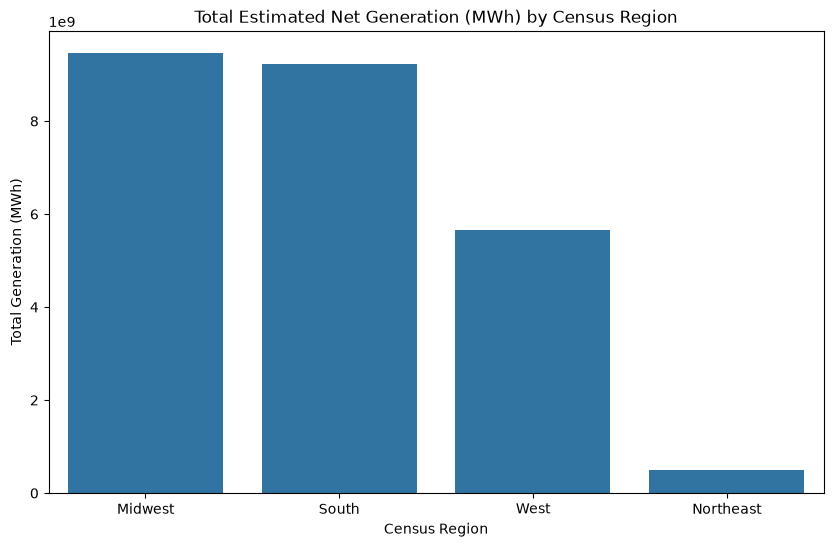

In [53]:
# Net Generation by Census Region
region_perf = wind_clean.groupby('census_region')['net_gen_proxy'].sum().reset_index()
region_perf = region_perf.sort_values(by='net_gen_proxy', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=region_perf, x='census_region', y='net_gen_proxy')
plt.title('Total Estimated Net Generation (MWh) by Census Region')
plt.xlabel('Census Region')
plt.ylabel('Total Generation (MWh)')
plt.show()


**Visualization 1 Interpretation:**
> The Midwest and South regions dominate total estimated Net Generation, at roughly 9.46 billion and 9.23 billion MWh respectively — together accounting for about 75% of the total across all four Census Regions. The West trails at 5.65 billion MWh, while the Northeast is far behind at just 0.50 billion MWh, reflecting both its smaller turbine count (2,612 vs. 25,106 in the Midwest) and weaker per-project performance. This confirms Objective 1: the Midwest and South are the clear priority regions for acquisition targeting.

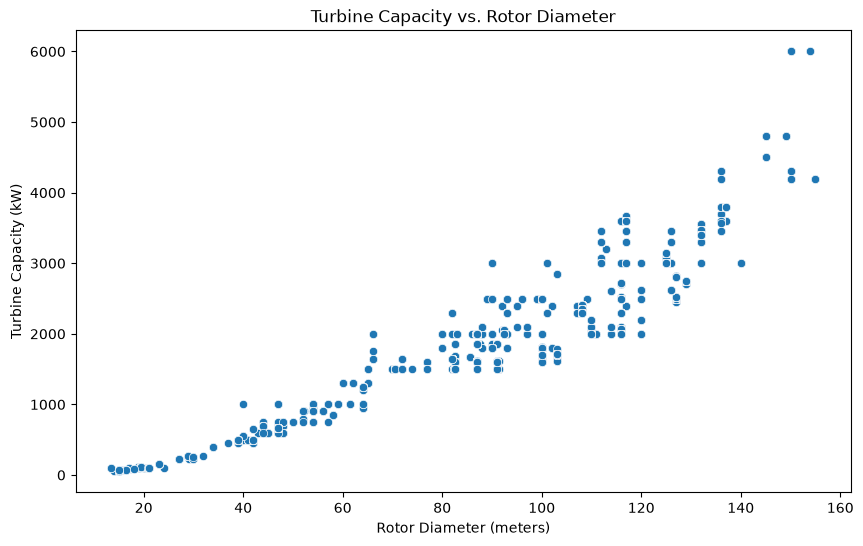

In [54]:
# Visualization 2
plt.figure(figsize=(10, 6))
sns.scatterplot(data=wind_clean, x='t_rd', y='t_cap')
plt.title('Turbine Capacity vs. Rotor Diameter')
plt.xlabel('Rotor Diameter (meters)')
plt.ylabel('Turbine Capacity (kW)')
plt.show()

**Visualization 2 Interpretation:**
> There is a strong, consistent positive relationship between rotor diameter and rated turbine capacity — larger rotors are paired with higher-capacity generators across the full range of the data, from under 20 meters/100 kW up to over 150 meters/6,000 kW. This supports Objective 2: rotor diameter is a reliable physical indicator of a turbine's power class, and the benchmark analysis (4.2) shows top-performing assets cluster around a rotor diameter of ~111 meters and hub height of ~86.5 meters.

---
## 5. Summary of Findings & Actionable Recommendations
*Methodological Note: This section bridges technical asset performance with strategic financial decisions. The objective is to translate physical turbine dimensions and geographic variables into concrete risk-mitigation and asset-acquisition strategies.*

### 5.1 Key Insights (Summary of Findings)
* **Geographic concentration:** The Midwest (9.46B MWh, 25,106 turbines) and South (9.23B MWh, 21,846 turbines) together make up about 75% of total estimated Net Generation. The South has the highest average per project (422,339 vs. Midwest's 376,895), meaning it performs better per turbine — even though the Midwest has more turbines overall.
* **Weak regions:** The Northeast is behind on every measure — lowest average (192,917), lowest median (188,982), and the smallest footprint (2,612 turbines, only 0.50B MWh total) — making it a low priority for now.
* **Performance benchmark:** The top 10% of turbines average a rated capacity of ~2,378 kW, a hub height of ~86.5 meters, and a rotor diameter of ~111.6 meters — this is the profile of a "high-performing" turbine.
* **Rotor diameter as a capacity signal:** Bigger rotors are consistently paired with higher-capacity turbines across the dataset.
* **Niche configurations:** A few specific models perform well above average despite having very few units — Nordex AW132/3300 (55 units, ~888,599 avg.), Vestas V136-3.7 (29 units, ~797,413 avg.), and Nordex AW132/3465 (79 units, ~688,204 avg.). These are uncommon setups that outperform the fleet average by a lot.

### 5.2 Actionable Recommendations
* **Prioritize the Midwest and South:** These two regions make up ~75% of total output and should be the main focus for acquisitions, with the South favored when per-project efficiency matters more than scale.
* **Use the benchmark profile as a screening filter:** Look for turbines close to 2,378 kW capacity, 86.5m hub height, and 111.6m rotor diameter — this profile matches the top 10% of historical performers.
* **Look closer at niche models:** Models like Nordex AW132/3300, Vestas V136-3.7, and Nordex AW132/3465 stand out and could be undervalued opportunities — but their small sample sizes (as few as 3-79 units) mean they need more verification before being fully relied on.
* **Deprioritize the Northeast** for now, given its weaker performance across every measure.

### 5.3 Limitations & Areas for Further Research
* **Estimated Net Generation, not real data:** Real Net Generation numbers weren't available at the turbine level, so this analysis uses an estimate instead: capacity × hours in a year × an estimated capacity factor (based on each state's wind strength). This gives a reasonable approximation, but it isn't the same as actual metered output, which would also reflect downtime, curtailment, and grid limits. Real numbers (e.g. from EIA-923) should be used to confirm these findings before making investment decisions.
* **Small sample sizes in niche findings:** Some "niche" models are based on very few turbines (3-79 units), so their strong performance could come from a few good locations rather than the model itself.
* **Missing technical data:** About 2-3% of turbines are missing spec data (rotor diameter, hub height, capacity), which were left out of spec-related analysis.
* **Electricity price data not used yet:** We collected electricity rate and bill data by state but didn't use it in this analysis — a future step could check if strong-performing regions also have different electricity prices.
* **Net Generation proxy uses project-level capacity:** `net_gen_proxy` was calculated using 
  `p_cap` (cumulative project capacity) applied at the turbine row level. For multi-turbine 
  projects, this means each turbine's row carries the full project's estimated generation, 
  which likely overstates totals for regions with larger average project sizes. A more precise 
  version would use per-turbine capacity (`t_cap`) instead. Regional rankings and general 
  patterns are still directionally useful, but absolute totals should be treated as rough estimates.
---

## 6. Data Dictionary & References

### 6.1 Data Dictionary

| Feature / Column | Data Type | Source | Description |
|:---|:---|:---|:---|
| case_id | integer | Original (USWTDB) | Unique identifier for each turbine |
| t_state | string | Original (USWTDB) | State abbreviation where the turbine is located |
| t_county | string | Original (USWTDB) | County where the turbine is located |
| t_fips | string | Original (USWTDB) | State and county FIPS code |
| p_name | string | Original (USWTDB) | Name of the wind power project |
| p_year | integer | Original (USWTDB) | Year the project became operational |
| p_tnum | integer | Original (USWTDB) | Number of turbines in the project |
| p_cap | float | Original (USWTDB) | Cumulative project capacity, in megawatts (MW) |
| t_manu | string | Original (USWTDB), standardized | Turbine manufacturer name (Siemens/Gamesa/Goldwind variants merged) |
| t_model | string | Original (USWTDB) | Turbine model name |
| t_cap | integer | Original (USWTDB) | Rated capacity of a single turbine, in kilowatts (kW) |
| t_hh | float | Original (USWTDB) | Turbine hub height, in meters |
| t_rd | float | Original (USWTDB) | Turbine rotor diameter, in meters |
| t_rsa | float | Original (USWTDB) | Turbine rotor swept area, in square meters |
| t_ttlh | float | Original (USWTDB) | Total turbine height (ground to blade tip), in meters |
| retrofit | integer | Original (USWTDB) | 1 if the turbine has been retrofitted, 0 if not |
| retrofit_year | float | Original (USWTDB), cleaned | Year of retrofit; filled with 0 where no retrofit occurred |
| t_conf_atr | integer | Original (USWTDB) | Confidence level (1-3) in the turbine's attribute data |
| t_conf_loc | integer | Original (USWTDB) | Confidence level (1-3) in the turbine's location data |
| xlong | float | Original (USWTDB) | Longitude of the turbine |
| ylat | float | Original (USWTDB) | Latitude of the turbine |
| MeanWindPower328ft | integer | Engineered (merged from windiest_states) | Mean wind power potential at 328ft for the turbine's state |
| capacity_factor_est | float | Engineered | Estimated capacity factor (0.20-0.45), scaled from state wind power potential |
| net_gen_proxy | float | Engineered | Estimated Net Generation (MWh) = p_cap × 8760 × capacity_factor_est |
| census_region | string | Engineered | US Census Region (Northeast/Midwest/South/West) derived from t_state |

### 6.2 References & Sources
* *Source 1*: U.S. Geological Survey (USGS) & Lawrence Berkeley National Laboratory (LBNL), The U.S. Wind Turbine Database (USWTDB), v5.3. Available at: https://gtech.usgs.gov/uwwtd/
* *Source 2*: State-level wind speed/power, electricity rate, and electricity bill datasets provided as part of the course project materials.
* *Source 3*: U.S. Census Bureau, Geographic Terms and Concepts - Census Regions and Divisions for standardized state-to-region mapping hierarchies.